In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 99.9 MB/s eta 0:00:00:00:010:01
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu

In [2]:
from ultralytics import YOLO
import os

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/dataclusterlabs
/kaggle/input/datasets/dataclusterlabs/indian-vehicle-dataset
/kaggle/input/datasets/dataclusterlabs/indian-vehicle-dataset/Indian_vehicle_dataset


In [4]:
import os

dataset_path = "/kaggle/input/datasets/dataclusterlabs/indian-vehicle-dataset/Indian_vehicle_dataset"

print(os.listdir(dataset_path))

['Datacluster Auto (113).xml', 'Datacluster Truck (188).jpg', '20230423_08_25_35_285_000_AA4h5dbDBoZwTj1JVM5gM6nWnIl1_T_3120_4160.jpg', '20210530_06_07_18_000_IgrGpcUr9VUkCKoJXEc6qmRsBQQ2_F_4000_3000.xml', '20230609_08_41_24_058_000_M2g0AUTsRgWanudCqhH14rhQwgQ2_F_3120_4160.jpg', '20210516_05_05_05_000_OgfflYWVtcZg5UlVKsTtIh0krh83_F_4016_3008.xml', '20210602_06_31_02_000_9WQPkiDGniaikLLMKfq2N6pTzGS2_F_4000_3000.jpg', 'Datacluster Truck (24).jpg', 'Datacluster Truck (185).xml', '20210603_16_05_53_000_jDFuE7jKOkcEFT9TdQNTtfsDDFs1_F_4096_3072.jpg', '20210518_11_45_56_000_x1Al88rRcbgbIm5Y4D4pjFVpufq2_F_4000_3000.jpg', '20230608_16_14_49_365_000_wDtXeDNcReeOz1MHnXAsjpuGY4V2_T_1844_4000.jpg', '20210602_06_31_02_000_9WQPkiDGniaikLLMKfq2N6pTzGS2_F_4000_3000.xml', 'Datacluster Truck (18).xml', '20230629_11_45_47_309_000_cxQ4BpIvcQOYnMur8gVEisGE6dr2_F_4160_3120.xml', 'Datacluster Truck (163).xml', '20230502_23_44_21_795_000_zXTk9yW8C8cbuRDpnPfT3Q7M1GC2_T_2048_1152.jpg', '20210601_21_22_16_000_an8

In [5]:
import os

base_path = "/kaggle/working/vehicle_dataset"

folders = [
    "images",
    "annotations"
]

for folder in folders:
    os.makedirs(os.path.join(base_path, folder), exist_ok=True)

print("Folders")

Folders


In [6]:
import os
import shutil

source_path = "/kaggle/input/datasets/dataclusterlabs/indian-vehicle-dataset/Indian_vehicle_dataset"

image_dest = "/kaggle/working/vehicle_dataset/images"
xml_dest = "/kaggle/working/vehicle_dataset/annotations"

for file in os.listdir(source_path):

    full_path = os.path.join(source_path, file)

    if file.endswith(".jpg"):
        shutil.copy(full_path, image_dest)

    elif file.endswith(".xml"):
        shutil.copy(full_path, xml_dest)

print("Images and XML files separated")

Images and XML files separated


In [7]:
print("Images:", len(os.listdir("/kaggle/working/vehicle_dataset/images")))
print("XML Files:", len(os.listdir("/kaggle/working/vehicle_dataset/annotations")))

Images: 100
XML Files: 100


In [8]:
import os
import xml.etree.ElementTree as ET

classes = ["auto", "bike", "car", "truck"]

xml_folder = "/kaggle/working/vehicle_dataset/annotations"
image_folder = "/kaggle/working/vehicle_dataset/images"

label_folder = "/kaggle/working/vehicle_dataset/labels"
os.makedirs(label_folder, exist_ok=True)

def convert_bbox(size, box):
    dw = 1.0 / size[0]
    dh = 1.0 / size[1]

    x = (box[0] + box[1]) / 2.0
    y = (box[2] + box[3]) / 2.0

    w = box[1] - box[0]
    h = box[3] - box[2]

    x *= dw
    w *= dw
    y *= dh
    h *= dh

    return (x, y, w, h)

for xml_file in os.listdir(xml_folder):

    if not xml_file.endswith(".xml"):
        continue

    tree = ET.parse(os.path.join(xml_folder, xml_file))
    root = tree.getroot()

    size = root.find("size")
    w = int(size.find("width").text)
    h = int(size.find("height").text)

    txt_filename = xml_file.replace(".xml", ".txt")
    txt_path = os.path.join(label_folder, txt_filename)

    with open(txt_path, "w") as out_file:

        for obj in root.iter("object"):

            cls = obj.find("name").text.lower()

            if cls not in classes:
                continue

            cls_id = classes.index(cls)

            xmlbox = obj.find("bndbox")

            xmin = float(xmlbox.find("xmin").text)
            xmax = float(xmlbox.find("xmax").text)
            ymin = float(xmlbox.find("ymin").text)
            ymax = float(xmlbox.find("ymax").text)

            bbox = convert_bbox((w, h), (xmin, xmax, ymin, ymax))

            out_file.write(
                str(cls_id) + " " +
                " ".join([str(a) for a in bbox]) + "\n"
            )


In [9]:
print("YOLO Labels:", len(os.listdir("/kaggle/working/vehicle_dataset/labels")))

YOLO Labels: 100


In [10]:
import os

label_path = "/kaggle/working/vehicle_dataset/labels"

for file in os.listdir(label_path):

    full_path = os.path.join(label_path, file)

    if os.path.getsize(full_path) > 0:

        print("Found valid label file:", file)

        with open(full_path, "r") as f:
            print(f.read())

        break

Found valid label file: 20210521_09_44_00_000_OgfflYWVtcZg5UlVKsTtIh0krh83_F_4016_3008.txt
0 0.8731233377659574 0.4058316733067729 0.2537533244680851 0.14594123505976092
0 0.6702293882978723 0.3923344123505976 0.14305186170212755 0.13413097609561755
0 0.5345063164893618 0.37166459163346616 0.11037566489361701 0.09954432270916334
0 0.4748121675531915 0.3661827689243028 0.038294547872340365 0.09870019920318722
0 0.11380152925531914 0.422953187250996 0.22760305851063828 0.3017480079681274



In [11]:
import os
import random
import shutil

image_path = "/kaggle/working/vehicle_dataset/images"
label_path = "/kaggle/working/vehicle_dataset/labels"

output_path = "/kaggle/working/final_dataset"

folders = [
    "train/images",
    "train/labels",
    "valid/images",
    "valid/labels",
    "test/images",
    "test/labels"
]

for folder in folders:
    os.makedirs(os.path.join(output_path, folder), exist_ok=True)

images = [f for f in os.listdir(image_path) if f.endswith(".jpg")]

random.shuffle(images)

train_split = 0.7
valid_split = 0.2

train_size = int(len(images) * train_split)
valid_size = int(len(images) * valid_split)

train_files = images[:train_size]
valid_files = images[train_size:train_size + valid_size]
test_files = images[train_size + valid_size:]

def copy_files(files, split):

    for file in files:

        image_src = os.path.join(image_path, file)

        label_file = file.replace(".jpg", ".txt")
        label_src = os.path.join(label_path, label_file)

        image_dst = os.path.join(output_path, split, "images", file)
        label_dst = os.path.join(output_path, split, "labels", label_file)

        shutil.copy(image_src, image_dst)

        if os.path.exists(label_src):
            shutil.copy(label_src, label_dst)

copy_files(train_files, "train")
copy_files(valid_files, "valid")
copy_files(test_files, "test")

print("Dataset split completed")

Dataset split completed


In [12]:
print(os.listdir("/kaggle/working/final_dataset"))

['test', 'train', 'valid']


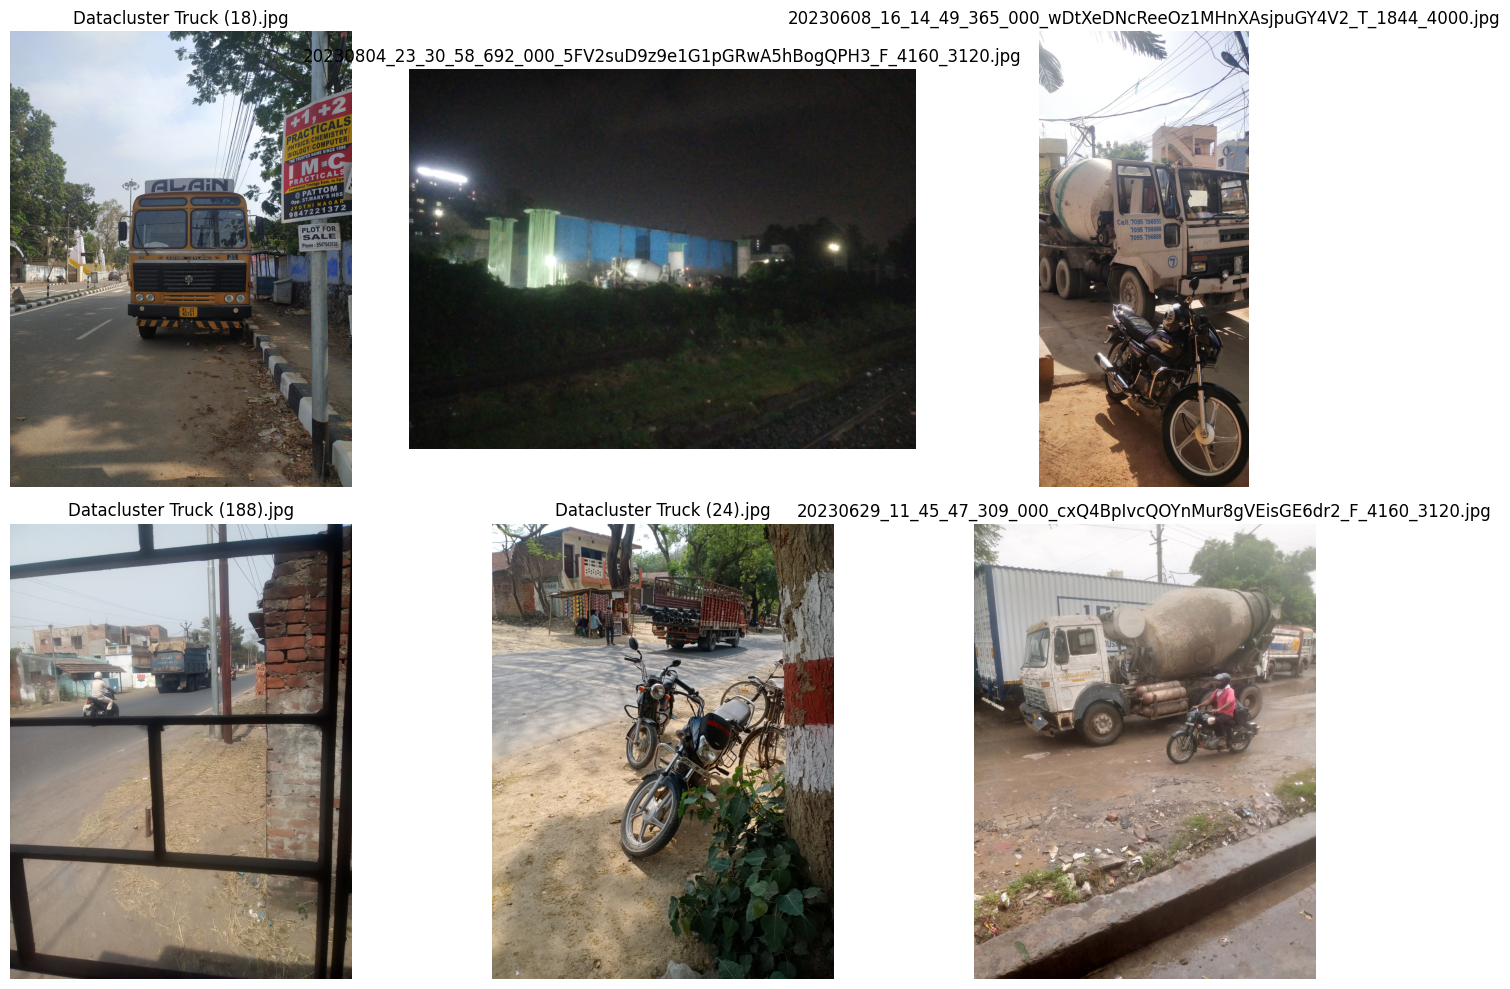

In [13]:
import os
import cv2
import matplotlib.pyplot as plt

train_image_path = "/kaggle/working/final_dataset/train/images"

images = os.listdir(train_image_path)[:6]

plt.figure(figsize=(15,10))

for i, img_name in enumerate(images):

    img_path = os.path.join(train_image_path, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(img_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
import os

base = "/kaggle/working/final_dataset"

train_images = len(os.listdir(f"{base}/train/images"))
train_labels = len(os.listdir(f"{base}/train/labels"))

valid_images = len(os.listdir(f"{base}/valid/images"))
valid_labels = len(os.listdir(f"{base}/valid/labels"))

test_images = len(os.listdir(f"{base}/test/images"))
test_labels = len(os.listdir(f"{base}/test/labels"))

total_images = train_images + valid_images + test_images

print("-"*50)
print("DATASET")
print("-"*50)

print(f"Total Images       : {total_images}")
print()

print("TRAIN SET")
print(f"Images             : {train_images}")
print(f"Labels             : {train_labels}")
print(f"Percentage         : {(train_images/total_images)*100:.2f}%")
print()

print("VALIDATION SET")
print(f"Images             : {valid_images}")
print(f"Labels             : {valid_labels}")
print(f"Percentage         : {(valid_images/total_images)*100:.2f}%")
print()

print("TEST SET")
print(f"Images             : {test_images}")
print(f"Labels             : {test_labels}")
print(f"Percentage         : {(test_images/total_images)*100:.2f}%")
print()

print("-"*50)
print("CLASSES USED")
print("-"*50)

classes = ["auto", "bike", "car", "truck"]

for i, cls in enumerate(classes):
    print(f"{i} -> {cls}")

--------------------------------------------------
DATASET
--------------------------------------------------
Total Images       : 100

TRAIN SET
Images             : 70
Labels             : 70
Percentage         : 70.00%

VALIDATION SET
Images             : 20
Labels             : 20
Percentage         : 20.00%

TEST SET
Images             : 10
Labels             : 10
Percentage         : 10.00%

--------------------------------------------------
CLASSES USED
--------------------------------------------------
0 -> auto
1 -> bike
2 -> car
3 -> truck
